In [141]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
import lightgbm as lgb

from sklearn.pipeline import Pipeline
import joblib as jb

In [2]:
df=pd.read_csv(r"C:\Users\shiva\OneDrive\Desktop\Property_Prediction\data\house_price_cleaned.csv",index_col=0 )

In [3]:
df.head().T

,11,56,83,230,249
ID,12,57,84,231,250
State,Karnataka,Karnataka,Karnataka,Karnataka,Karnataka
City,Bangalore,Bangalore,Bangalore,Bangalore,Bangalore
Locality,North-East,East,North-East,North-East,East
Property_Type,Apartment,Apartment,Independent House,Apartment,Independent House
BHK,5,5,4,1,2
Size_in_SqFt,3988,3276,3936,999,1022
Price_in_Lakhs,465.38,139.64,401.88,342.81,68.09
Price_per_SqFt,0.12,0.04,0.1,0.34,0.07
Year_Built,2022,1997,1999,2006,2009


In [4]:
df.info()

<class 'pandas.DataFrame'>
Index: 4144 entries, 11 to 249981
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   4144 non-null   int64  
 1   State                4144 non-null   str    
 2   City                 4144 non-null   str    
 3   Locality             4144 non-null   str    
 4   Property_Type        4144 non-null   str    
 5   BHK                  4144 non-null   int64  
 6   Size_in_SqFt         4144 non-null   int64  
 7   Price_in_Lakhs       4144 non-null   float64
 8   Price_per_SqFt       4144 non-null   float64
 9   Year_Built           4144 non-null   int64  
 10  Furnished_Status     4144 non-null   str    
 11  Floor_No             4144 non-null   int64  
 12  Total_Floors         4144 non-null   int64  
 13  Age_of_Property      4144 non-null   int64  
 14  Nearby_Schools       4144 non-null   int64  
 15  Nearby_Hospitals     4144 non-null   int64  
 16  F

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,4144.0,125418.885135,72570.677433,12.00,62936.25,125095.50,188631.000,249982.00
BHK,4144.0,3.006274,1.423895,1.00,2.00,3.00,4.000,5.00
Size_in_SqFt,4144.0,2749.871380,1292.878271,501.00,1644.00,2747.00,3865.500,4999.00
Price_in_Lakhs,4144.0,258.456639,141.256308,10.11,138.18,258.36,383.725,499.94
Price_per_SqFt,4144.0,0.131429,0.130030,0.00,0.05,0.09,0.160,0.94
Year_Built,4144.0,2006.622104,9.838427,1990.00,1998.00,2007.00,2015.000,2023.00
Floor_No,4144.0,15.037645,9.014272,0.00,7.00,15.00,23.000,30.00
Total_Floors,4144.0,15.520029,8.712236,1.00,8.00,16.00,23.000,30.00
Age_of_Property,4144.0,18.377896,9.838427,2.00,10.00,18.00,27.000,35.00
Nearby_Schools,4144.0,5.522442,2.861090,1.00,3.00,6.00,8.000,10.00


In [6]:
df.describe(include="object").T

C:\Users\shiva\AppData\Local\Temp\ipykernel_15660\1274302342.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object").T


,count,unique,top,freq
State,4144,1,Karnataka,4144
City,4144,1,Bangalore,4144
Locality,4144,8,East,557
Property_Type,4144,3,Apartment,1386
Furnished_Status,4144,3,Semi-furnished,1383
Facing,4144,4,North,1062
Availability_Status,4144,2,Under_Construction,2084


## Droping irrelevent columns

In [7]:
df.drop("ID",axis=1,inplace=True)
df.drop("State",axis=1,inplace=True)
df.drop("City",axis=1,inplace=True)

In [8]:
df.head().T

,11,56,83,230,249
Locality,North-East,East,North-East,North-East,East
Property_Type,Apartment,Apartment,Independent House,Apartment,Independent House
BHK,5,5,4,1,2
Size_in_SqFt,3988,3276,3936,999,1022
Price_in_Lakhs,465.38,139.64,401.88,342.81,68.09
Price_per_SqFt,0.12,0.04,0.1,0.34,0.07
Year_Built,2022,1997,1999,2006,2009
Furnished_Status,Furnished,Semi-furnished,Furnished,Semi-furnished,Furnished
Floor_No,6,9,2,15,17
Total_Floors,24,14,6,25,9


## Dividing into categorical and numerical features

In [9]:
categorical_features = df.select_dtypes(include=['object']).columns
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns

C:\Users\shiva\AppData\Local\Temp\ipykernel_15660\2973811786.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = df.select_dtypes(include=['object']).columns


In [10]:
categorical_features


Index(['Locality', 'Property_Type', 'Furnished_Status', 'Facing',
       'Availability_Status'],
      dtype='str')

In [11]:
numerical_features

Index(['BHK', 'Size_in_SqFt', 'Price_in_Lakhs', 'Price_per_SqFt', 'Year_Built',
       'Floor_No', 'Total_Floors', 'Age_of_Property', 'Nearby_Schools',
       'Nearby_Hospitals'],
      dtype='str')

# EDA

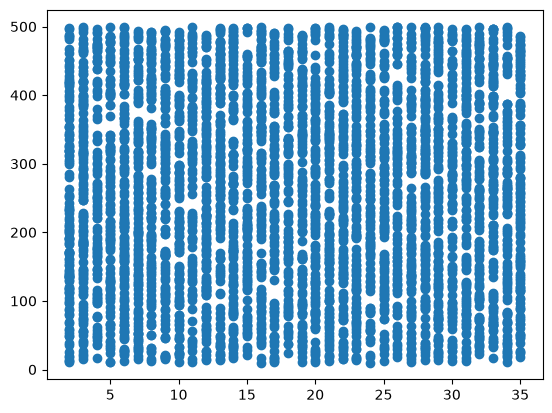

In [12]:
plt.scatter(df["Age_of_Property"],df["Price_in_Lakhs"])

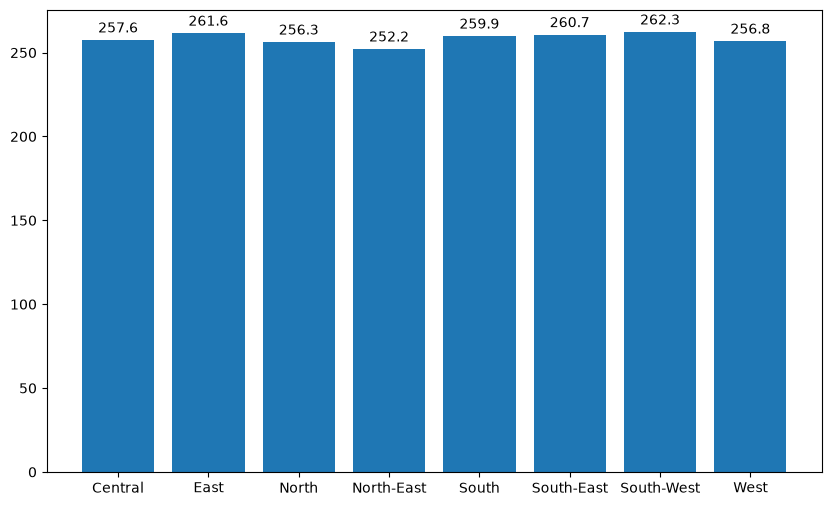

In [13]:
avg_df = df.groupby("Locality")["Price_in_Lakhs"].mean().reset_index()
plt.figure(figsize=(10, 6))
bars = plt.bar(avg_df["Locality"], avg_df["Price_in_Lakhs"])
#formatted labels at top of each bar
plt.bar_label(bars, fmt="%.1f", padding=3);

### Data is Balanced regionally

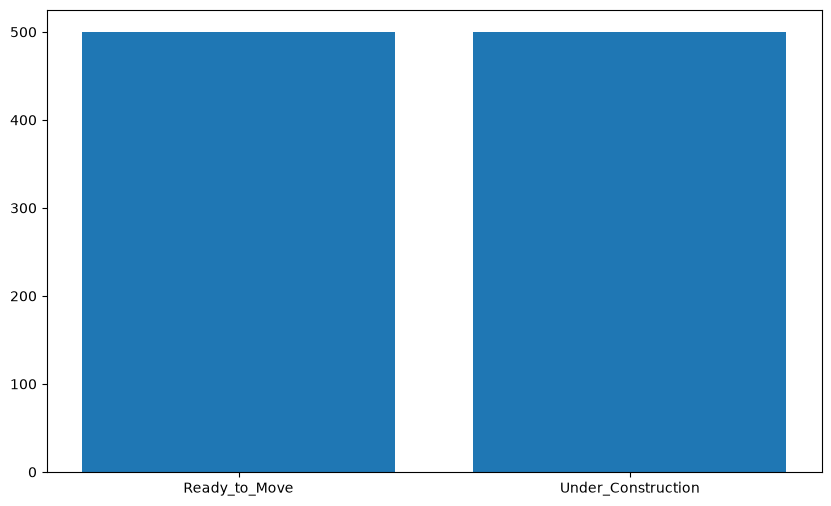

In [14]:
plt.figure(figsize=(10, 6))
bars = plt.bar(df["Availability_Status"], df["Price_in_Lakhs"])

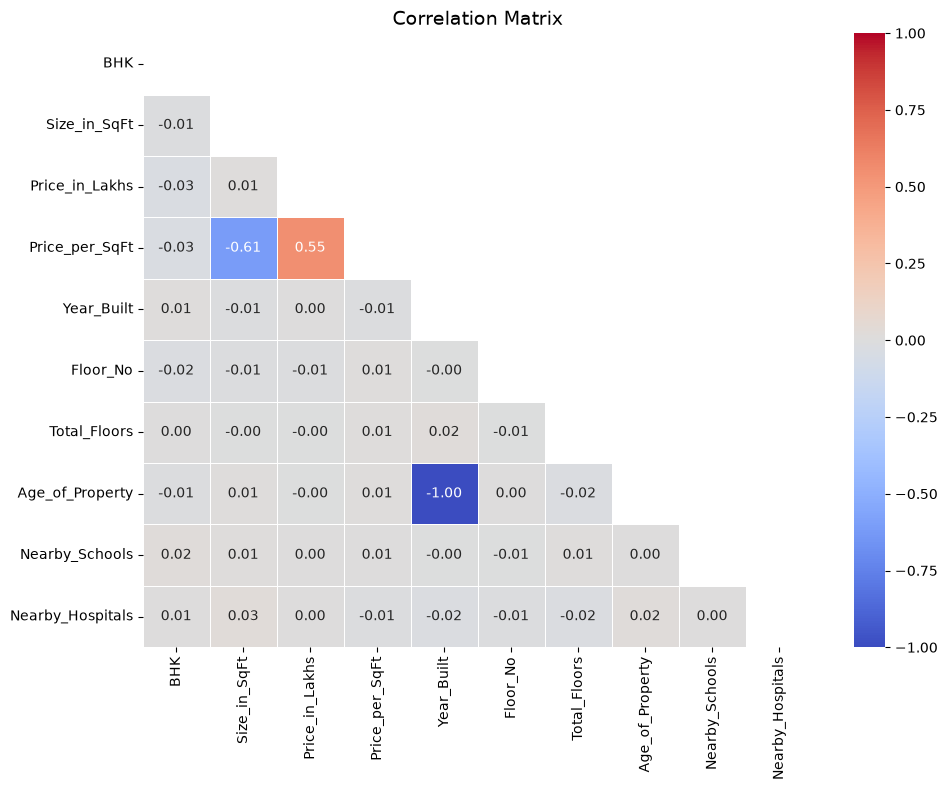

In [15]:
numric_df=df.select_dtypes(include=['int64', 'float64'])
corr=numric_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(10, 8))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Matrix', fontsize=14)
plt.tight_layout()

### Size and price per square feet are highly correlated

### Train test split

In [16]:
X=df.drop("Price_in_Lakhs", axis=1)
Y=df["Price_in_Lakhs"]

In [17]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

### Performing feature engineering 

In [73]:

class feature_addition(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_out = X.copy() if isinstance(X, pd.DataFrame) else pd.DataFrame(X)
        
        # Safely drop prohibited columns if present
        unwanted_cols = ["Price_per_SqFt", "Year_Built", "Nearby_Hospitals", "Nearby_Schools"]
        X_out = X_out.drop(columns=[c for c in unwanted_cols if c in X_out.columns])

        # Engineer Top Floor Flag & Elevation Ratio
        if "Floor_No" in X_out.columns and "Total_Floors" in X_out.columns:
            X_out["Is_Top_Floor"] = (X_out["Floor_No"] == X_out["Total_Floors"]).astype(int)
            X_out["Floor_Ratio"] = np.where(
                X_out["Total_Floors"] > 0,
                X_out["Floor_No"] / X_out["Total_Floors"],
                0
            )
        return X_out

# Cleaning

In [74]:
class NullImputer(BaseEstimator, TransformerMixin):
    def __init__(self, locality_mean_cols=None):
        if locality_mean_cols is None:
            self.locality_mean_cols = ["Size_in_SqFt", "Age_of_Property"]
        else:
            self.locality_mean_cols = locality_mean_cols

    def fit(self, X, y=None):
        X_df = X.copy() if isinstance(X, pd.DataFrame) else pd.DataFrame(X)

        self.locality_means_ = {}
        self.global_means_ = {}

        if "Locality" in X_df.columns:
            for col in self.locality_mean_cols:
                if col in X_df.columns:
                    self.locality_means_[col] = (
                        X_df.groupby("Locality")[col].mean().to_dict()
                    )
                    self.global_means_[col] = X_df[col].mean()

        self.num_medians_ = {}
        self.cat_modes_ = {}

        numeric_cols = [
            c for c in X_df.select_dtypes(include=[np.number]).columns
            if c not in self.locality_mean_cols
        ]
        categorical_cols = X_df.select_dtypes(include=["object", "category"]).columns

        for col in numeric_cols:
            self.num_medians_[col] = X_df[col].median()

        for col in categorical_cols:
            mode_series = X_df[col].mode()
            self.cat_modes_[col] = (
                mode_series.iloc[0] if not mode_series.empty else "Unknown"
            )

        return self

    def transform(self, X):
        X_df = X.copy() if isinstance(X, pd.DataFrame) else pd.DataFrame(X)

        if "Locality" in X_df.columns:
            for col in self.locality_mean_cols:
                if col in X_df.columns:
                    loc_mean_mapped = X_df["Locality"].map(
                        self.locality_means_.get(col, {})
                    )
                    X_df[col] = X_df[col].fillna(loc_mean_mapped)
                    X_df[col] = X_df[col].fillna(
                        self.global_means_.get(col, 0)
                    )

        for col, median_val in self.num_medians_.items():
            if col in X_df.columns:
                X_df[col] = X_df[col].fillna(median_val)

        for col, mode_val in self.cat_modes_.items():
            if col in X_df.columns:
                X_df[col] = X_df[col].fillna(mode_val)

        return X_df

### Making Pipelines


In [83]:
from sklearn.preprocessing import TargetEncoder

# Target encode high-cardinality features, OneHot encode low-cardinality ones
high_card_cats = ['Locality']
low_card_cats = ['Property_Type', 'Furnished_Status', 'Facing', 'Availability_Status']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), final_num_cols),
        ('target_cat', TargetEncoder(smooth="auto"), high_card_cats),
        ('onehot_cat', OneHotEncoder(drop='first', handle_unknown='ignore'), low_card_cats)
    ]
)

In [108]:
Liner_reg = Pipeline(steps=[
    ('null_imputer', NullImputer()),  # 1. Fill missing values first
    ('feature_addition', feature_addition()),   # 2. Engineer features on clean data
    ('preprocessor', preprocessor),             # 3. Scale and One-Hot Encode
    ('regressor', LinearRegression())           # 4. Fit model
])

In [85]:
Lasso_reg=Pipeline(steps=[
    ('null_imputer', NullImputer()),
    ('feature_addition', feature_addition()),
    ('preprocessor', preprocessor),
    ('regressor', Lasso())
])


In [86]:
Ridge_reg=Pipeline(steps=[
    ('null_imputer', NullImputer()),
    ('feature_addition', feature_addition()),
    ('preprocessor', preprocessor),
    ('regressor', Ridge())
    ])


In [87]:
lgbm_reg=Pipeline(steps=[
    ('null_imputer', NullImputer()),
    ('feature_addition', feature_addition()),
    ('preprocessor', preprocessor),
    ('regressor', lgb.LGBMRegressor())
])

In [103]:
linear_model.fit(X_train, Y_train)

C:\Users\shiva\AppData\Local\Temp\ipykernel_15660\3569567013.py:29: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_df.select_dtypes(include=["object", "category"]).columns


,"regressor regressor: object, default=NoneRegressor object such as derived from:class:`~sklearn.base.RegressorMixin`. This regressor willautomatically be cloned each time prior to fitting. If `regressor isNone`, :class:`~sklearn.linear_model.LinearRegression` is created and used.",Pipeline(step...egression())])
,"func func: function, default=NoneFunction to apply to `y` before passing to :meth:`fit`. Cannot be setat the same time as `transformer`. If `func is None`, the function used will bethe identity function. If `func` is set, `inverse_func` also needs to beprovided. The function needs to return a 2-dimensional array.",<ufunc 'log1p'>
,"inverse_func inverse_func: function, default=NoneFunction to apply to the prediction of the regressor. Cannot be set atthe same time as `transformer`. The inverse function is used to returnpredictions to the same space of the original training labels. If`inverse_func` is set, `func` also needs to be provided. The inversefunction needs to return a 2-dimensional array.",<ufunc 'expm1'>
,"transformer transformer: object, default=NoneEstimator object such as derived from:class:`~sklearn.base.TransformerMixin`. Cannot be set at the same timeas `func` and `inverse_func`. If `transformer is None` as well as`func` and `inverse_func`, the transformer will be an identitytransformer. Note that the transformer will be cloned during fitting.Also, the transformer is restricting `y` to be a numpy array.",None
,"check_inverse check_inverse: bool, default=TrueWhether to check that `transform` followed by `inverse_transform`or `func` followed by `inverse_func` leads to the original targets.",True
Name,Type,Value
regressor_ regressor_: objectFitted regressor.,Pipeline,Pipeline(step...egression())])
transformer_ transformer_: objectTransformer used in :meth:`fit` and :meth:`predict`.,FunctionTransformer,FunctionTrans...validate=True)
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('null_imputer', ...), ('feature_addition', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None


In [104]:
Y_preds=Liner_reg.predict(X_test)

In [107]:
Liner_reg.score(X_test,Y_test)

-0.0024704468032215043

In [91]:
Ridge_reg.fit(X_train, Y_train)

C:\Users\shiva\AppData\Local\Temp\ipykernel_15660\3569567013.py:29: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_df.select_dtypes(include=["object", "category"]).columns


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('null_imputer', ...), ('feature_addition', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,locality_mean_cols,"['Size_in_SqFt', 'Age_of_Property']"
Name,Type,Value
cat_modes_,dict,"{'Av...us': 'Un...on', 'Facing': 'South', 'Fu...us': 'Se...ed', 'Lo...ty': 'East', ...}"
global_means_,dict,"{'Ag...ty': np.float64(18.37496229260935), 'Si...Ft': np.float64(2735.5176470588235)}"
locality_means_,dict,"{'Ag...ty': {'Central': 19.00943396226415, 'East': 18.972350230414747, 'North': 18.35421686746988, 'No...st': 18.8560411311054, ...}, 'Si...Ft': {'Central': 2688.228773584906, 'East': 2717.4861751152075, 'North': 2595.178313253012, 'No...st': 2725.4370179948587, ...}}"
num_medians_,dict,"{'BHK': np.float64(3.0), 'Fl...No': np.float64(15.0), 'Ne...ls': np.float64(6.0), 'Ne...ls': np.float64(6.0), ...}"
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('target_cat', ...), ...]"


In [92]:
Ridge_reg.score(X_test,Y_test)

-0.0024365732555522435

In [93]:
Lasso_reg.fit(X_train, Y_train)

C:\Users\shiva\AppData\Local\Temp\ipykernel_15660\3569567013.py:29: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_df.select_dtypes(include=["object", "category"]).columns


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('null_imputer', ...), ('feature_addition', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,locality_mean_cols,"['Size_in_SqFt', 'Age_of_Property']"
Name,Type,Value
cat_modes_,dict,"{'Av...us': 'Un...on', 'Facing': 'South', 'Fu...us': 'Se...ed', 'Lo...ty': 'East', ...}"
global_means_,dict,"{'Ag...ty': np.float64(18.37496229260935), 'Si...Ft': np.float64(2735.5176470588235)}"
locality_means_,dict,"{'Ag...ty': {'Central': 19.00943396226415, 'East': 18.972350230414747, 'North': 18.35421686746988, 'No...st': 18.8560411311054, ...}, 'Si...Ft': {'Central': 2688.228773584906, 'East': 2717.4861751152075, 'North': 2595.178313253012, 'No...st': 2725.4370179948587, ...}}"
num_medians_,dict,"{'BHK': np.float64(3.0), 'Fl...No': np.float64(15.0), 'Ne...ls': np.float64(6.0), 'Ne...ls': np.float64(6.0), ...}"
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('target_cat', ...), ...]"


In [94]:
Lasso_reg.score(X_test,Y_test)

-0.0026258568838470886

In [95]:
lgbm_reg.fit(X_train, Y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000248 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 672
[LightGBM] [Info] Number of data points in the train set: 3315, number of used features: 16
[LightGBM] [Info] Start training from score 258.299704


C:\Users\shiva\AppData\Local\Temp\ipykernel_15660\3569567013.py:29: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_df.select_dtypes(include=["object", "category"]).columns


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('null_imputer', ...), ('feature_addition', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,locality_mean_cols,"['Size_in_SqFt', 'Age_of_Property']"
Name,Type,Value
cat_modes_,dict,"{'Av...us': 'Un...on', 'Facing': 'South', 'Fu...us': 'Se...ed', 'Lo...ty': 'East', ...}"
global_means_,dict,"{'Ag...ty': np.float64(18.37496229260935), 'Si...Ft': np.float64(2735.5176470588235)}"
locality_means_,dict,"{'Ag...ty': {'Central': 19.00943396226415, 'East': 18.972350230414747, 'North': 18.35421686746988, 'No...st': 18.8560411311054, ...}, 'Si...Ft': {'Central': 2688.228773584906, 'East': 2717.4861751152075, 'North': 2595.178313253012, 'No...st': 2725.4370179948587, ...}}"
num_medians_,dict,"{'BHK': np.float64(3.0), 'Fl...No': np.float64(15.0), 'Ne...ls': np.float64(6.0), 'Ne...ls': np.float64(6.0), ...}"
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('target_cat', ...), ...]"


In [96]:
lgbm_reg.score(X_test,Y_test)

-0.09933393809849278

In [109]:

rf_pipeline = Pipeline(steps=[
    ('null_imputer', NullImputer()),
    ('feature_addition', feature_addition()),
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

In [128]:
rf_pipeline.fit(X_train, Y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](17,)","['ID','State','City',...,'Nearby_Hospitals','Facing','Availability_Status']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,17
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('ohe', ...), ('scaler', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset

In [139]:
rf_pipeline.score(X_test,Y_test)

0.9858591499689167

In [142]:
jb.dump(rf_pipeline, 'rf_pipeline.pkl')

['rf_pipeline.pkl']